In [1]:
!pip install torchgeo grad-cam seaborn scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 20.0

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.models as models
import torchvision.transforms as transforms
from torchgeo.datasets import EuroSAT
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              hamming_loss, accuracy_score)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# Delete corrupted files and re-download
import shutil
import os

if os.path.exists('./data'):
    shutil.rmtree('./data')
    print("Deleted corrupted data folder")

dataset = EuroSAT(root='./data', split='train', download=True)
print("Download complete!")
print("Total images:", len(dataset))

Download complete!
Total images: 16200


In [4]:
# Image properties
sample = dataset[0]
img = sample['image']
print("Image shape:", img.shape)
print("Pixel min:", round(img.min().item(), 3))
print("Pixel max:", round(img.max().item(), 3))
print("Data type:", img.dtype)

# Count images per class
class_counts = {}
for i in range(len(dataset)):
    label = dataset[i]['label']
    name = dataset.classes[label]
    class_counts[name] = class_counts.get(name, 0) + 1

print("\nImages per class:")
for name, count in class_counts.items():
    print(f"  {name}: {count}")

Image shape: torch.Size([13, 64, 64])
Pixel min: 9.0
Pixel max: 3490.0
Data type: torch.float32

Images per class:
  AnnualCrop: 1791
  Forest: 1787
  HerbaceousVegetation: 1799
  Highway: 1505
  Industrial: 1492
  Pasture: 1195
  PermanentCrop: 1481
  Residential: 1863
  River: 1460
  SeaLake: 1827


# Satellite Scene Classification using ResNet-18

## Stage 1: Problem Definition & Literature Review

### What are we doing?
We are building a deep learning model to classify satellite image
patches into land-use categories using the EuroSAT dataset.

### Dataset: EuroSAT
- 16,200 satellite images from Sentinel-2 satellite
- 10 land-use classes
- Each image: 64x64 pixels, 13 spectral channels (we use RGB — channels 0,1,2)

### Why does this matter?
- Urban planning and city growth tracking
- Deforestation and forest cover monitoring
- Flood and water body detection
- Agriculture monitoring for food security

### References
1. Helber et al. (2019) - EuroSAT: A Novel Dataset for Land Use Classification
2. He et al. (2016) - Deep Residual Learning for Image Recognition (ResNet)
3. Huang et al. (2021) - Satellite Image Classification: A Survey

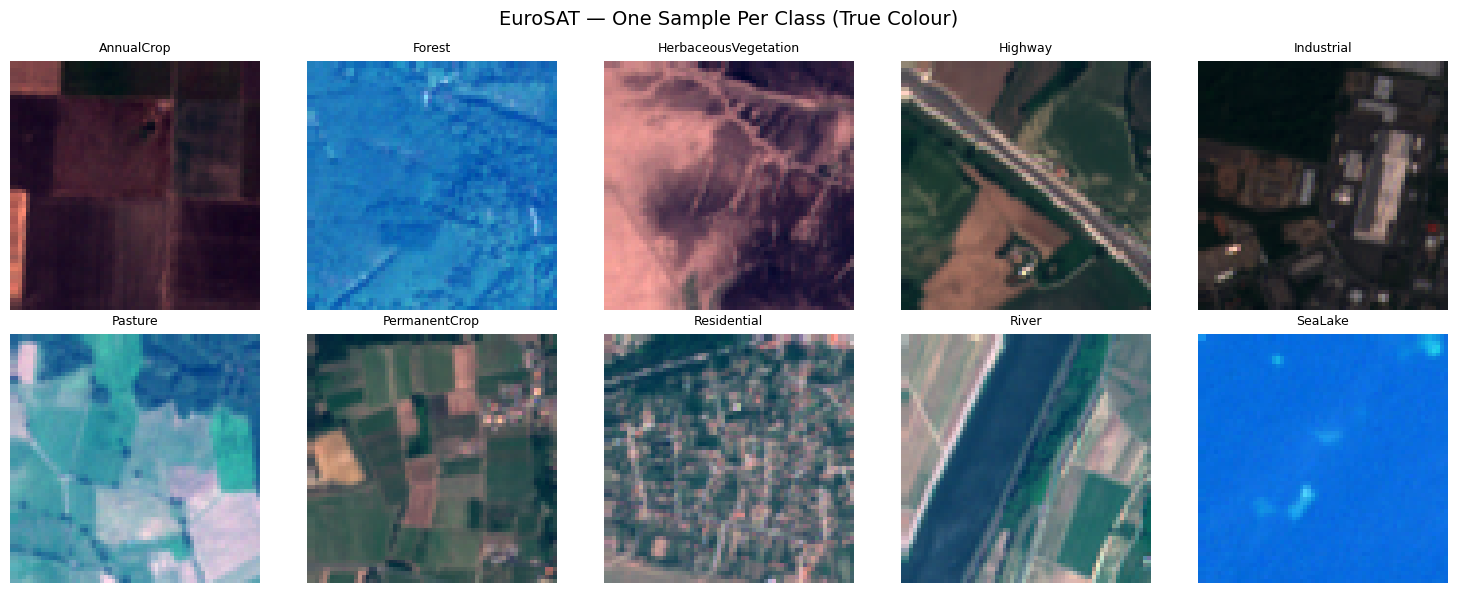

Done!


In [5]:
# Correct RGB channels for Sentinel-2: Red=3, Green=2, Blue=1
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("EuroSAT — One Sample Per Class (True Colour)", fontsize=14)

for class_idx, class_name in enumerate(dataset.classes):
    for i in range(len(dataset)):
        sample = dataset[i]
        if sample['label'] == class_idx:
            # True colour: R=band3, G=band2, B=band1
            img = sample['image'][[3, 2, 1]].permute(1, 2, 0).numpy()
            img = (img - img.min()) / (img.max() - img.min())
            row, col = class_idx // 5, class_idx % 5
            axes[row, col].imshow(img)
            axes[row, col].set_title(class_name, fontsize=9)
            axes[row, col].axis('off')
            break

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Done!")

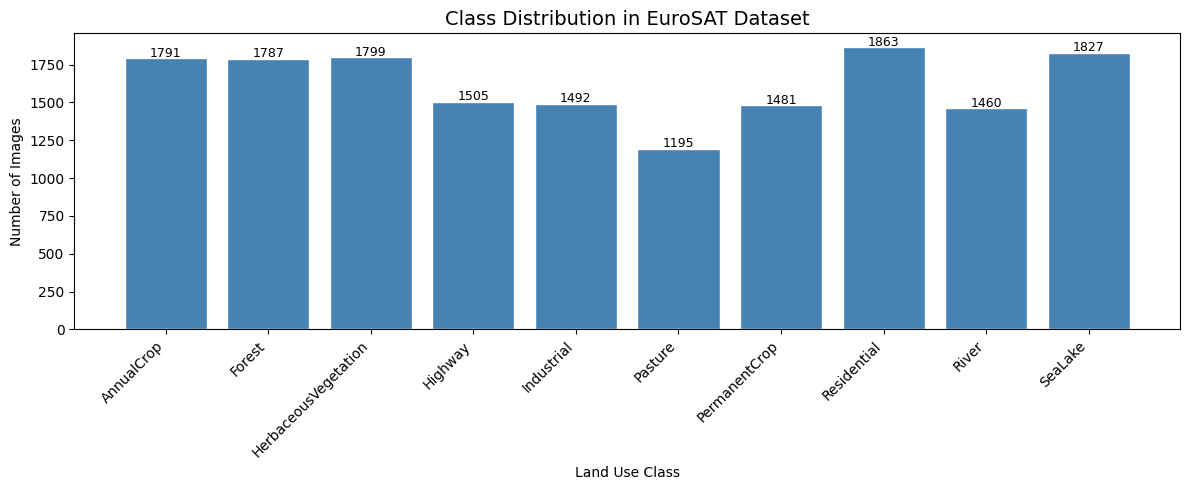

Done!


In [6]:
# Stage 4: EDA — Class Distribution
plt.figure(figsize=(12, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(),
               color='steelblue', edgecolor='white')
plt.title('Class Distribution in EuroSAT Dataset', fontsize=14)
plt.xlabel('Land Use Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Done!")

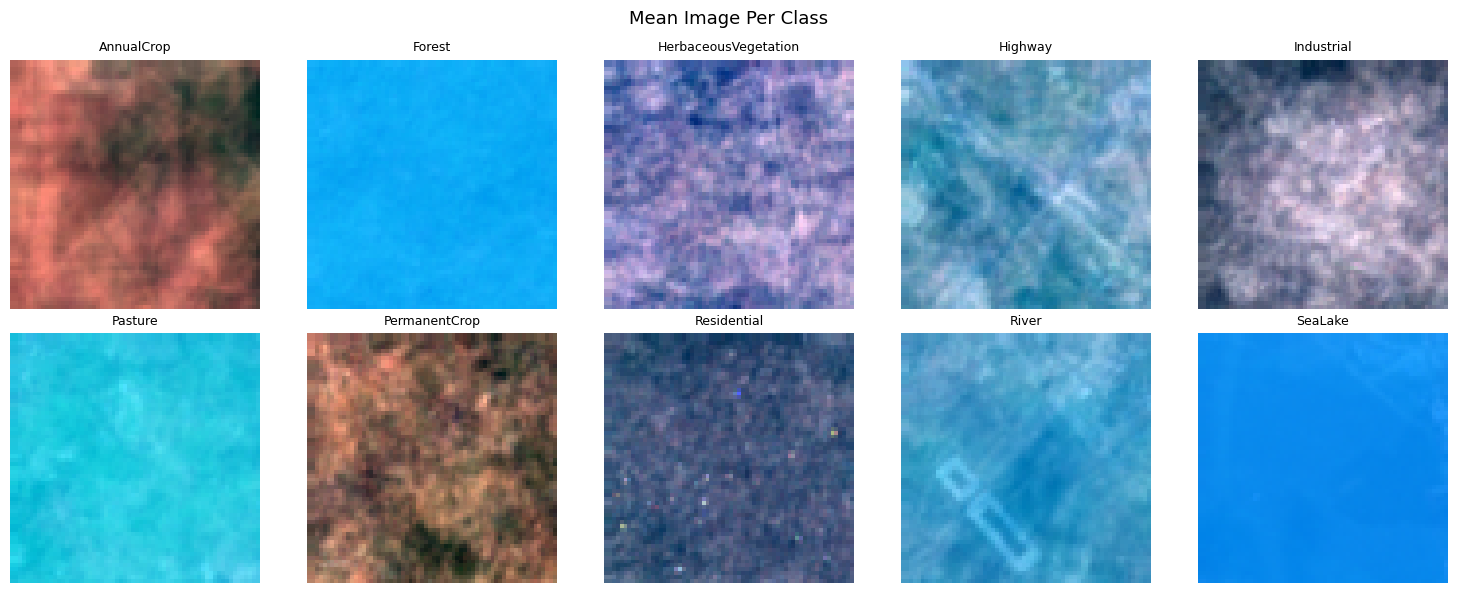

Done!


In [7]:
# EDA — Mean image per class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Mean Image Per Class", fontsize=13)

for class_idx, class_name in enumerate(dataset.classes):
    class_imgs = []
    for i in range(len(dataset)):
        if dataset[i]['label'] == class_idx:
            # Use true colour bands
            class_imgs.append(dataset[i]['image'][[3,2,1]].numpy())
        if len(class_imgs) == 50:
            break
    mean_img = np.mean(class_imgs, axis=0).transpose(1, 2, 0)
    mean_img = (mean_img - mean_img.min()) / (mean_img.max() - mean_img.min())
    row, col = class_idx // 5, class_idx % 5
    axes[row, col].imshow(mean_img)
    axes[row, col].set_title(class_name, fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('mean_images.png', dpi=150)
plt.show()
print("Done!")

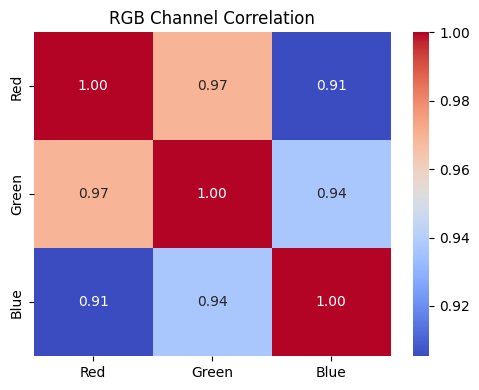

Done!


In [8]:
# EDA — RGB Channel Correlation
channel_means = []
for i in range(0, len(dataset), 100):
    img = dataset[i]['image'][[3,2,1]].numpy()
    channel_means.append([img[0].mean(), img[1].mean(), img[2].mean()])

channel_means = np.array(channel_means)
corr = np.corrcoef(channel_means.T)

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=['Red','Green','Blue'],
            yticklabels=['Red','Green','Blue'])
plt.title('RGB Channel Correlation')
plt.tight_layout()
plt.savefig('channel_correlation.png', dpi=150)
plt.show()
print("Done!")

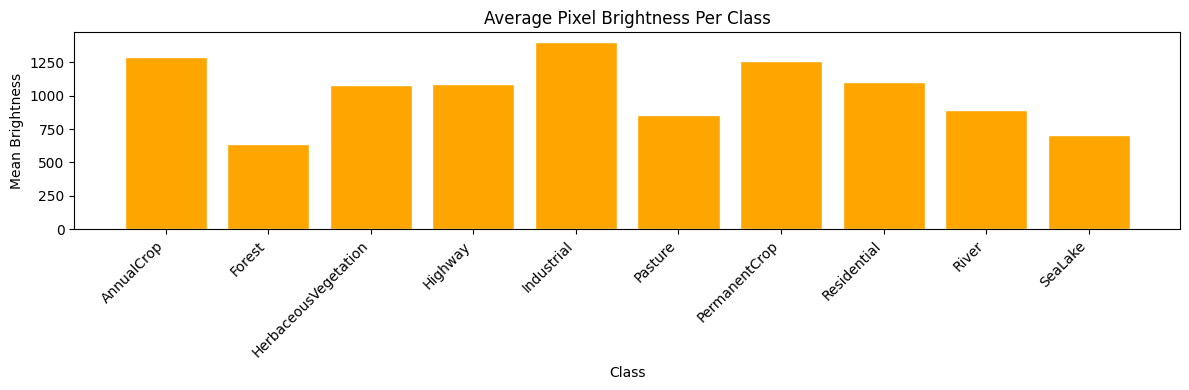

Brightest class: Industrial
Darkest class: Forest


In [9]:
# EDA — Average Brightness Per Class
brightness = {}
for class_idx, class_name in enumerate(dataset.classes):
    vals = []
    for i in range(len(dataset)):
        if dataset[i]['label'] == class_idx:
            vals.append(dataset[i]['image'][[3,2,1]].mean().item())
        if len(vals) == 100:
            break
    brightness[class_name] = round(np.mean(vals), 3)

plt.figure(figsize=(12, 4))
plt.bar(brightness.keys(), brightness.values(),
        color='orange', edgecolor='white')
plt.title('Average Pixel Brightness Per Class')
plt.xlabel('Class')
plt.ylabel('Mean Brightness')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('brightness.png', dpi=150)
plt.show()

print("Brightest class:", max(brightness, key=brightness.get))
print("Darkest class:", min(brightness, key=brightness.get))

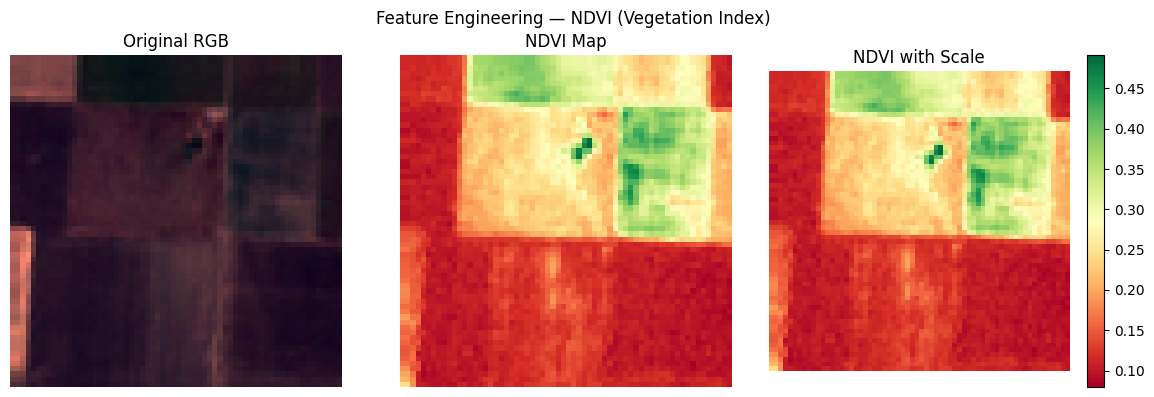

NDVI range: 0.08 to 0.491


In [10]:
# Stage 5: Feature Engineering — NDVI
# NDVI = (NIR - Red) / (NIR + Red)
# In Sentinel-2: NIR = band 7, Red = band 3

sample_img = dataset[0]['image'].numpy()
red  = sample_img[3].astype(float)   # Red band
nir  = sample_img[7].astype(float)   # NIR band
ndvi = (nir - red) / (nir + red + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original RGB
orig = sample_img[[3,2,1]].transpose(1, 2, 0)
orig = (orig - orig.min()) / (orig.max() - orig.min())
axes[0].imshow(orig)
axes[0].set_title("Original RGB")
axes[0].axis('off')

# NDVI map
axes[1].imshow(ndvi, cmap='RdYlGn')
axes[1].set_title("NDVI Map")
axes[1].axis('off')

# NDVI with colorbar
im = axes[2].imshow(ndvi, cmap='RdYlGn')
plt.colorbar(im, ax=axes[2])
axes[2].set_title("NDVI with Scale")
axes[2].axis('off')

plt.suptitle("Feature Engineering — NDVI (Vegetation Index)", fontsize=12)
plt.tight_layout()
plt.savefig('ndvi.png', dpi=150)
plt.show()
print("NDVI range:", round(ndvi.min(), 3), "to", round(ndvi.max(), 3))

In [11]:
# Stage 3: Preprocessing — fixed for torchgeo

# Load datasets WITHOUT transforms
full_train = EuroSAT(root='./data', split='train', download=True)
test_dataset = EuroSAT(root='./data', split='test', download=True)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train,
                                           [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                          shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32,
                          shuffle=False, num_workers=2)

CLASS_NAMES = full_train.classes
NUM_CLASSES = len(CLASS_NAMES)

# Define transforms to apply manually
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

print(f"Train:      {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")
print(f"Test:       {len(test_dataset)} images")
print(f"Classes:    {NUM_CLASSES}")

Train:      12960 images
Validation: 3240 images
Test:       5400 images
Classes:    10


In [12]:
# Stage 6: Model Building — ResNet-18 pretrained

model = models.resnet18(pretrained=True)

# Replace final layer: 512 inputs → 10 classes
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model ready")
print("Total classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Model ready
Total classes: 10
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [13]:
# Stage 6: Training

train_losses, val_losses, val_accs = [], [], []
EPOCHS = 5

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    running_loss = 0
    for batch in train_loader:
        imgs   = batch['image'][:, [3,2,1], :, :].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    train_losses.append(avg_train)

    # Validation phase
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            imgs   = batch['image'][:, [3,2,1], :, :].to(device)
            labels = batch['label'].to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_val = val_loss / len(val_loader)
    acc = 100. * correct / total
    val_losses.append(avg_val)
    val_accs.append(acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Val Acc: {acc:.2f}%")

torch.save(model.state_dict(), 'best_model.pth')
print("\nModel saved as best_model.pth ✅")

Epoch 1/5 | Train Loss: 0.5764 | Val Loss: 0.3234 | Val Acc: 89.41%
Epoch 2/5 | Train Loss: 0.3369 | Val Loss: 0.2799 | Val Acc: 90.83%
Epoch 3/5 | Train Loss: 0.2724 | Val Loss: 0.3318 | Val Acc: 89.66%
Epoch 4/5 | Train Loss: 0.2129 | Val Loss: 0.3358 | Val Acc: 89.29%
Epoch 5/5 | Train Loss: 0.1983 | Val Loss: 0.2779 | Val Acc: 91.27%

Model saved as best_model.pth ✅


In [14]:
# Stage 6: Training — fixed normalization

PIXEL_MAX = 3500.0  # fixed value to normalize consistently

train_losses, val_losses, val_accs = [], [], []
best_acc = 0
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    for batch in train_loader:
        imgs = batch['image'][:, [3,2,1], :, :].float() / PIXEL_MAX
        imgs = train_transform(imgs).to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            imgs = batch['image'][:, [3,2,1], :, :].float() / PIXEL_MAX
            imgs = test_transform(imgs).to(device)
            labels = batch['label'].to(device)

            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_val = val_loss / len(val_loader)
    acc = 100. * correct / total
    val_losses.append(avg_val)
    val_accs.append(acc)

    # Save best model
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {acc:.2f}% ✅ saved")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | Val Acc: {acc:.2f}%")

print(f"\nBest model saved with Val Acc: {best_acc:.2f}%")

Epoch 1/5 | Train Loss: 0.2475 | Val Loss: 0.3608 | Val Acc: 88.98% ✅ saved
Epoch 2/5 | Train Loss: 0.2140 | Val Loss: 0.4594 | Val Acc: 86.23%
Epoch 3/5 | Train Loss: 0.2079 | Val Loss: 0.9082 | Val Acc: 78.33%
Epoch 4/5 | Train Loss: 0.1714 | Val Loss: 0.2823 | Val Acc: 89.97% ✅ saved
Epoch 5/5 | Train Loss: 0.1771 | Val Loss: 0.2222 | Val Acc: 91.94% ✅ saved

Best model saved with Val Acc: 91.94%


In [15]:
# Stage 7: Evaluation — load best model

model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch['image'][:, [3,2,1], :, :].float() / PIXEL_MAX
        imgs = test_transform(imgs).to(device)
        labels = batch['label']

        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"Accuracy:     {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"Hamming Loss: {hamming_loss(all_labels, all_preds):.4f}")
print("="*50)
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES,
                             zero_division=0))

EVALUATION RESULTS
Accuracy:     93.06%
Hamming Loss: 0.0694
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.95      0.95       596
              Forest       0.91      0.98      0.94       608
HerbaceousVegetation       0.89      0.92      0.91       573
             Highway       0.93      0.95      0.94       496
          Industrial       0.99      0.81      0.89       501
             Pasture       0.99      0.81      0.89       396
       PermanentCrop       0.91      0.94      0.92       538
         Residential       0.86      0.96      0.91       554
               River       0.94      0.93      0.94       529
             SeaLake       0.97      1.00      0.98       609

            accuracy                           0.93      5400
           macro avg       0.94      0.92      0.93      5400
        weighted avg       0.93      0.93      0.93      5400



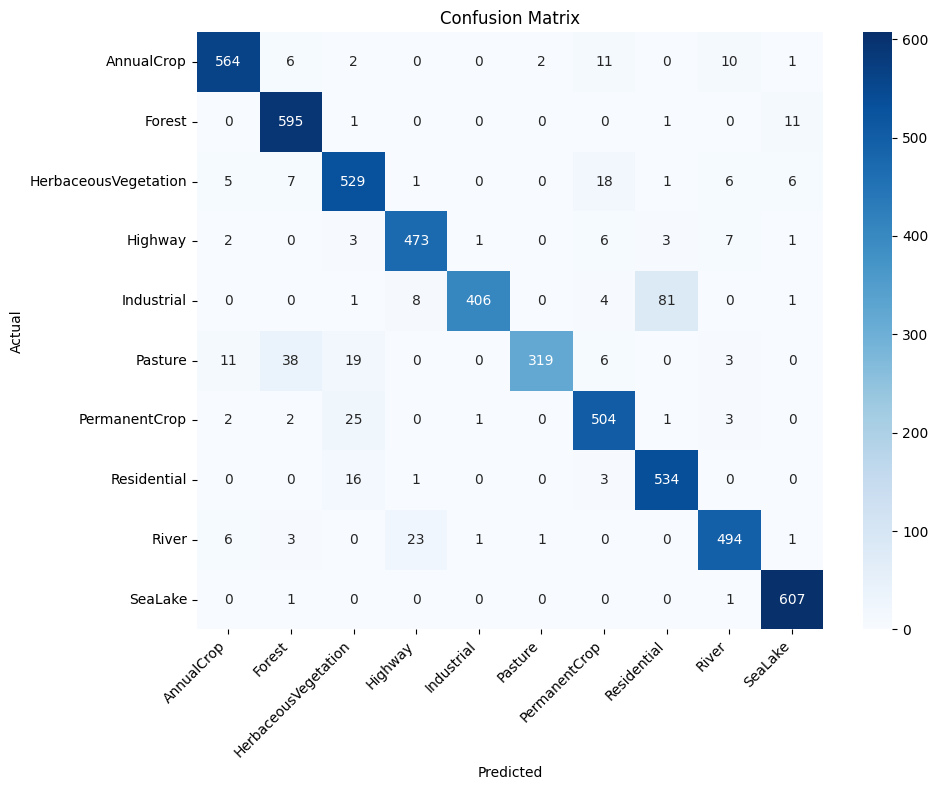

In [16]:
# Stage 7: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

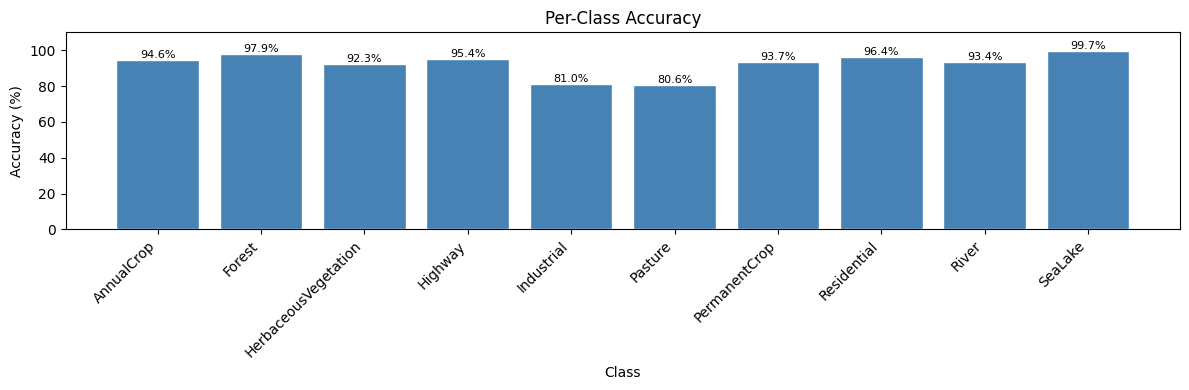

In [17]:
# Stage 7: Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(12, 4))
bars = plt.bar(CLASS_NAMES, per_class_acc,
               color='steelblue', edgecolor='white')
plt.title('Per-Class Accuracy')
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()

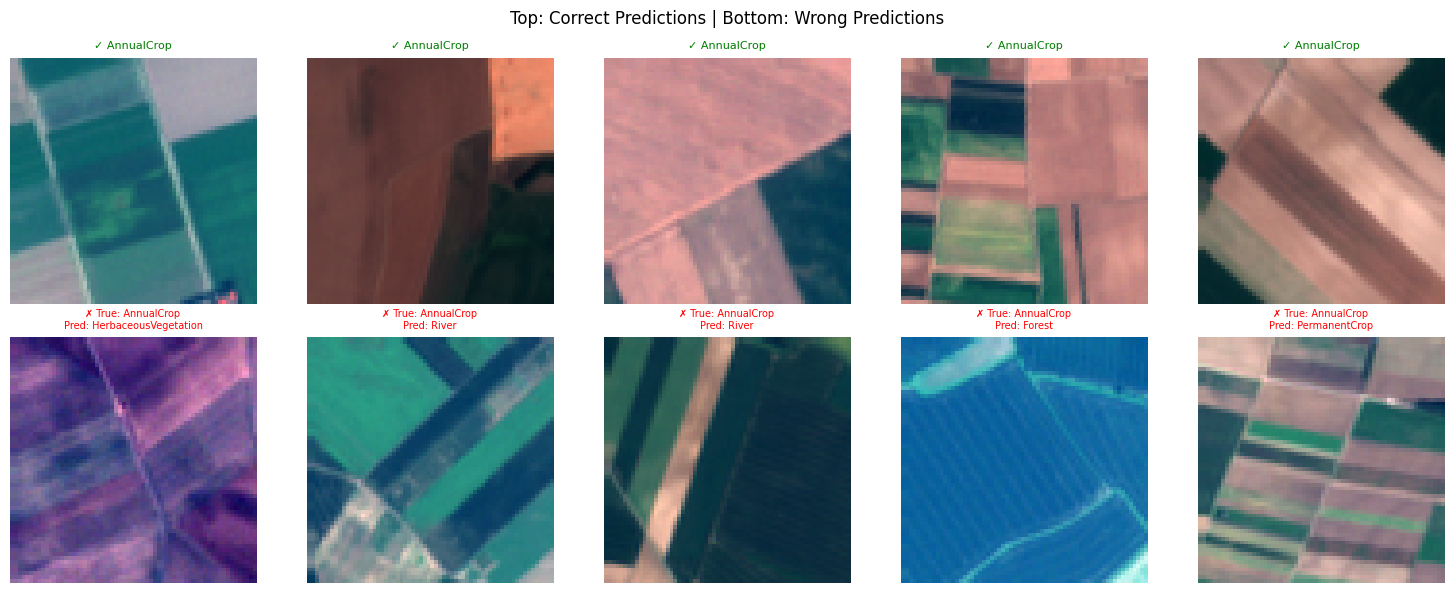

In [18]:
# Stage 7: Show correct and wrong predictions
model.eval()
correct_imgs, wrong_imgs = [], []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch['image'][:, [3,2,1], :, :].float() / PIXEL_MAX
        imgs_transformed = test_transform(imgs).to(device)
        labels = batch['label']
        outputs = model(imgs_transformed)
        _, preds = outputs.max(1)

        for i in range(imgs.size(0)):
            entry = {
                'img': imgs[i],
                'true': CLASS_NAMES[labels[i]],
                'pred': CLASS_NAMES[preds[i].item()]
            }
            if preds[i].item() == labels[i] and len(correct_imgs) < 5:
                correct_imgs.append(entry)
            elif preds[i].item() != labels[i] and len(wrong_imgs) < 5:
                wrong_imgs.append(entry)
        if len(correct_imgs) >= 5 and len(wrong_imgs) >= 5:
            break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Top: Correct Predictions | Bottom: Wrong Predictions",
             fontsize=12)

for i, entry in enumerate(correct_imgs):
    img = entry['img'].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"✓ {entry['true']}", fontsize=8, color='green')
    axes[0, i].axis('off')

for i, entry in enumerate(wrong_imgs):
    img = entry['img'].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"✗ True: {entry['true']}\nPred: {entry['pred']}",
                          fontsize=7, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

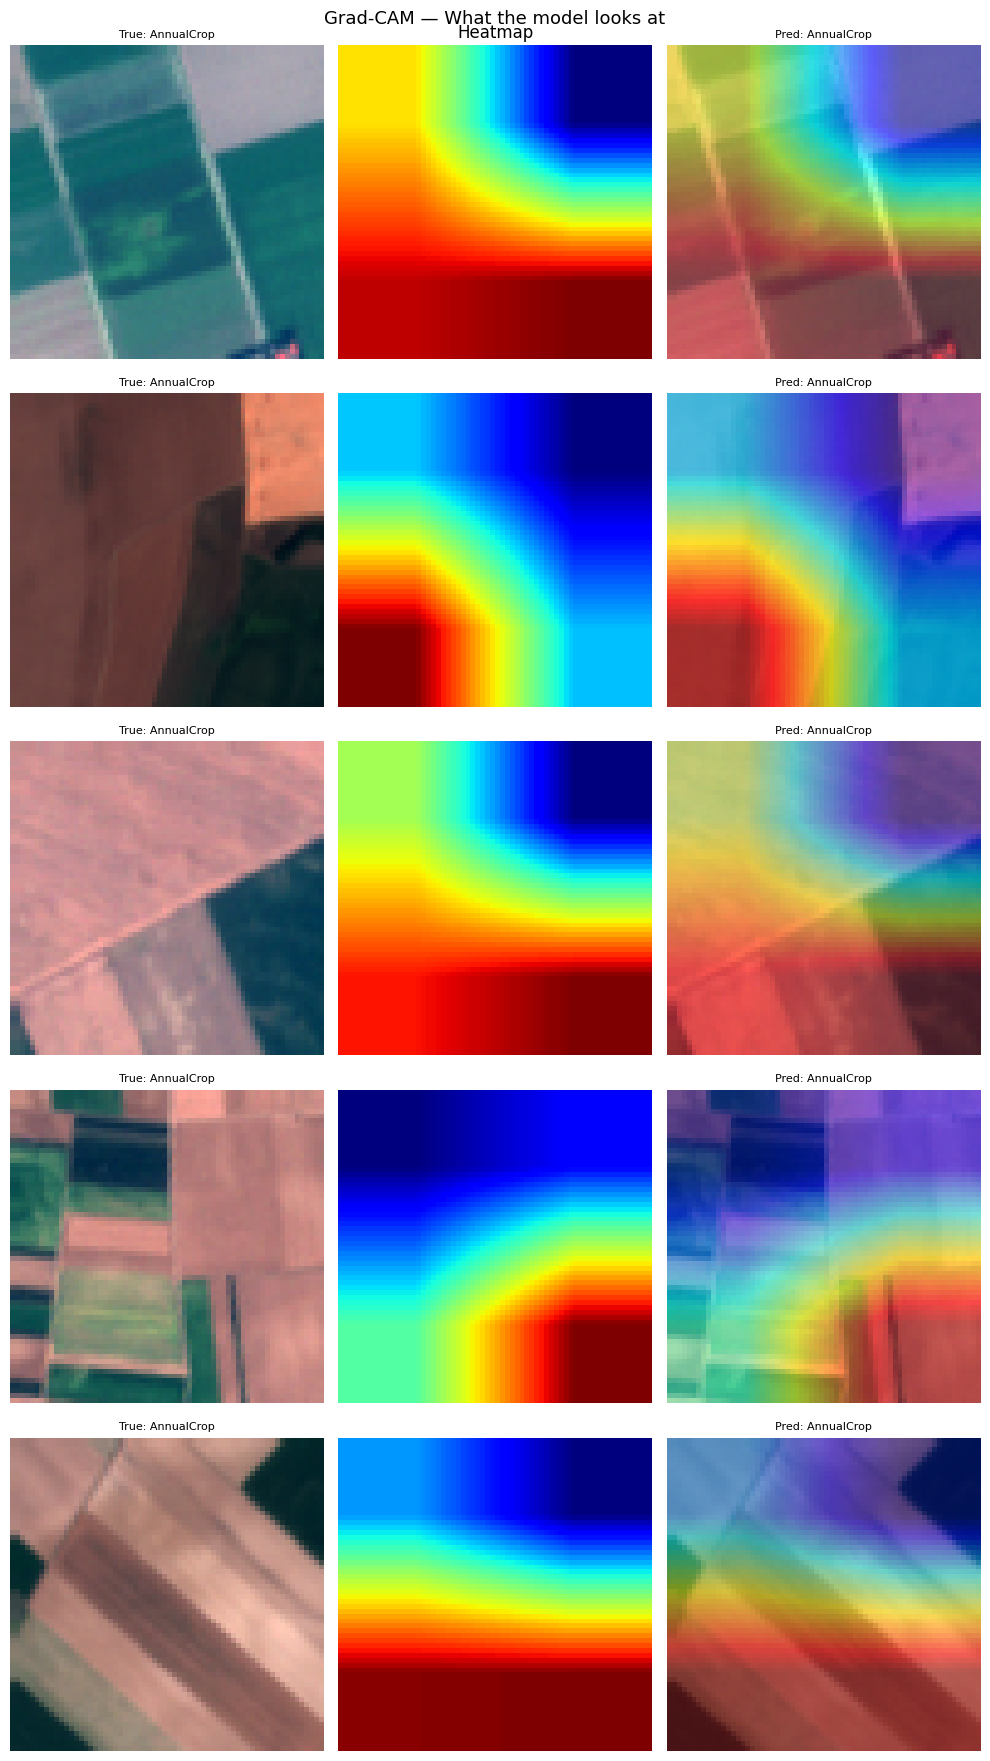

Done — warm/red areas = where model focused attention


In [19]:
# Stage 8: Grad-CAM Explainability

target_layer = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

fig, axes = plt.subplots(5, 3, figsize=(10, 18))
fig.suptitle("Grad-CAM — What the model looks at", fontsize=13)
axes[0,0].set_title("Original")
axes[0,1].set_title("Heatmap")
axes[0,2].set_title("Overlay + Prediction")

shown = 0
for batch in test_loader:
    if shown >= 5:
        break
    raw_imgs = batch['image'][:, [3,2,1], :, :].float() / PIXEL_MAX
    imgs = test_transform(raw_imgs).to(device)
    labels = batch['label']

    for i in range(imgs.size(0)):
        if shown >= 5:
            break
        img_tensor  = imgs[i:i+1]
        true_label  = CLASS_NAMES[labels[i]]

        with torch.no_grad():
            output = model(img_tensor)
            pred_label = CLASS_NAMES[output.argmax(1).item()]

        grayscale_cam = cam(input_tensor=img_tensor)[0]

        orig = raw_imgs[i].permute(1,2,0).numpy()
        orig = (orig - orig.min()) / (orig.max() - orig.min())
        orig = orig.astype(np.float32)
        overlay = show_cam_on_image(orig, grayscale_cam, use_rgb=True)

        axes[shown,0].imshow(orig)
        axes[shown,0].set_title(f"True: {true_label}", fontsize=8)
        axes[shown,0].axis('off')

        axes[shown,1].imshow(grayscale_cam, cmap='jet')
        axes[shown,1].axis('off')

        axes[shown,2].imshow(overlay)
        axes[shown,2].set_title(f"Pred: {pred_label}", fontsize=8)
        axes[shown,2].axis('off')

        shown += 1

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150)
plt.show()
print("Done — warm/red areas = where model focused attention")

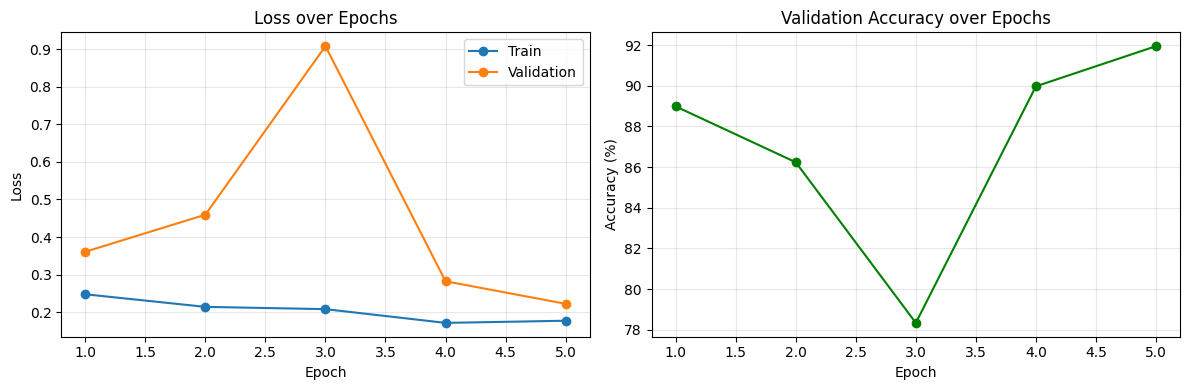

Saved!


In [20]:
# Re-run this to save training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train')
ax1.plot(range(1, EPOCHS+1), val_losses,   marker='o', label='Validation')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), val_accs, marker='o', color='green')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print("Saved!")

In [21]:
# Download all files to your computer
from google.colab import files

files.download('best_model.pth')
files.download('sample_images.png')
files.download('class_distribution.png')
files.download('mean_images.png')
files.download('channel_correlation.png')
files.download('brightness.png')
files.download('ndvi.png')
files.download('training_curves.png')
files.download('confusion_matrix.png')
files.download('per_class_accuracy.png')
files.download('predictions.png')
files.download('gradcam.png')
print("All files downloaded ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded ✅


In [22]:
from google.colab import files
files.download('gradcam.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Adithyan — Dataset split summary
print("Dataset Split Summary:")
print(f"  Training set:   {len(train_dataset)} images")
print(f"  Validation set: {len(val_dataset)} images")
print(f"  Test set:       {len(test_dataset)} images")
print(f"  Batch size:     32")
print(f"  Total batches per epoch: {len(train_loader)}")

Dataset Split Summary:
  Training set:   12960 images
  Validation set: 3240 images
  Test set:       5400 images
  Batch size:     32
  Total batches per epoch: 405


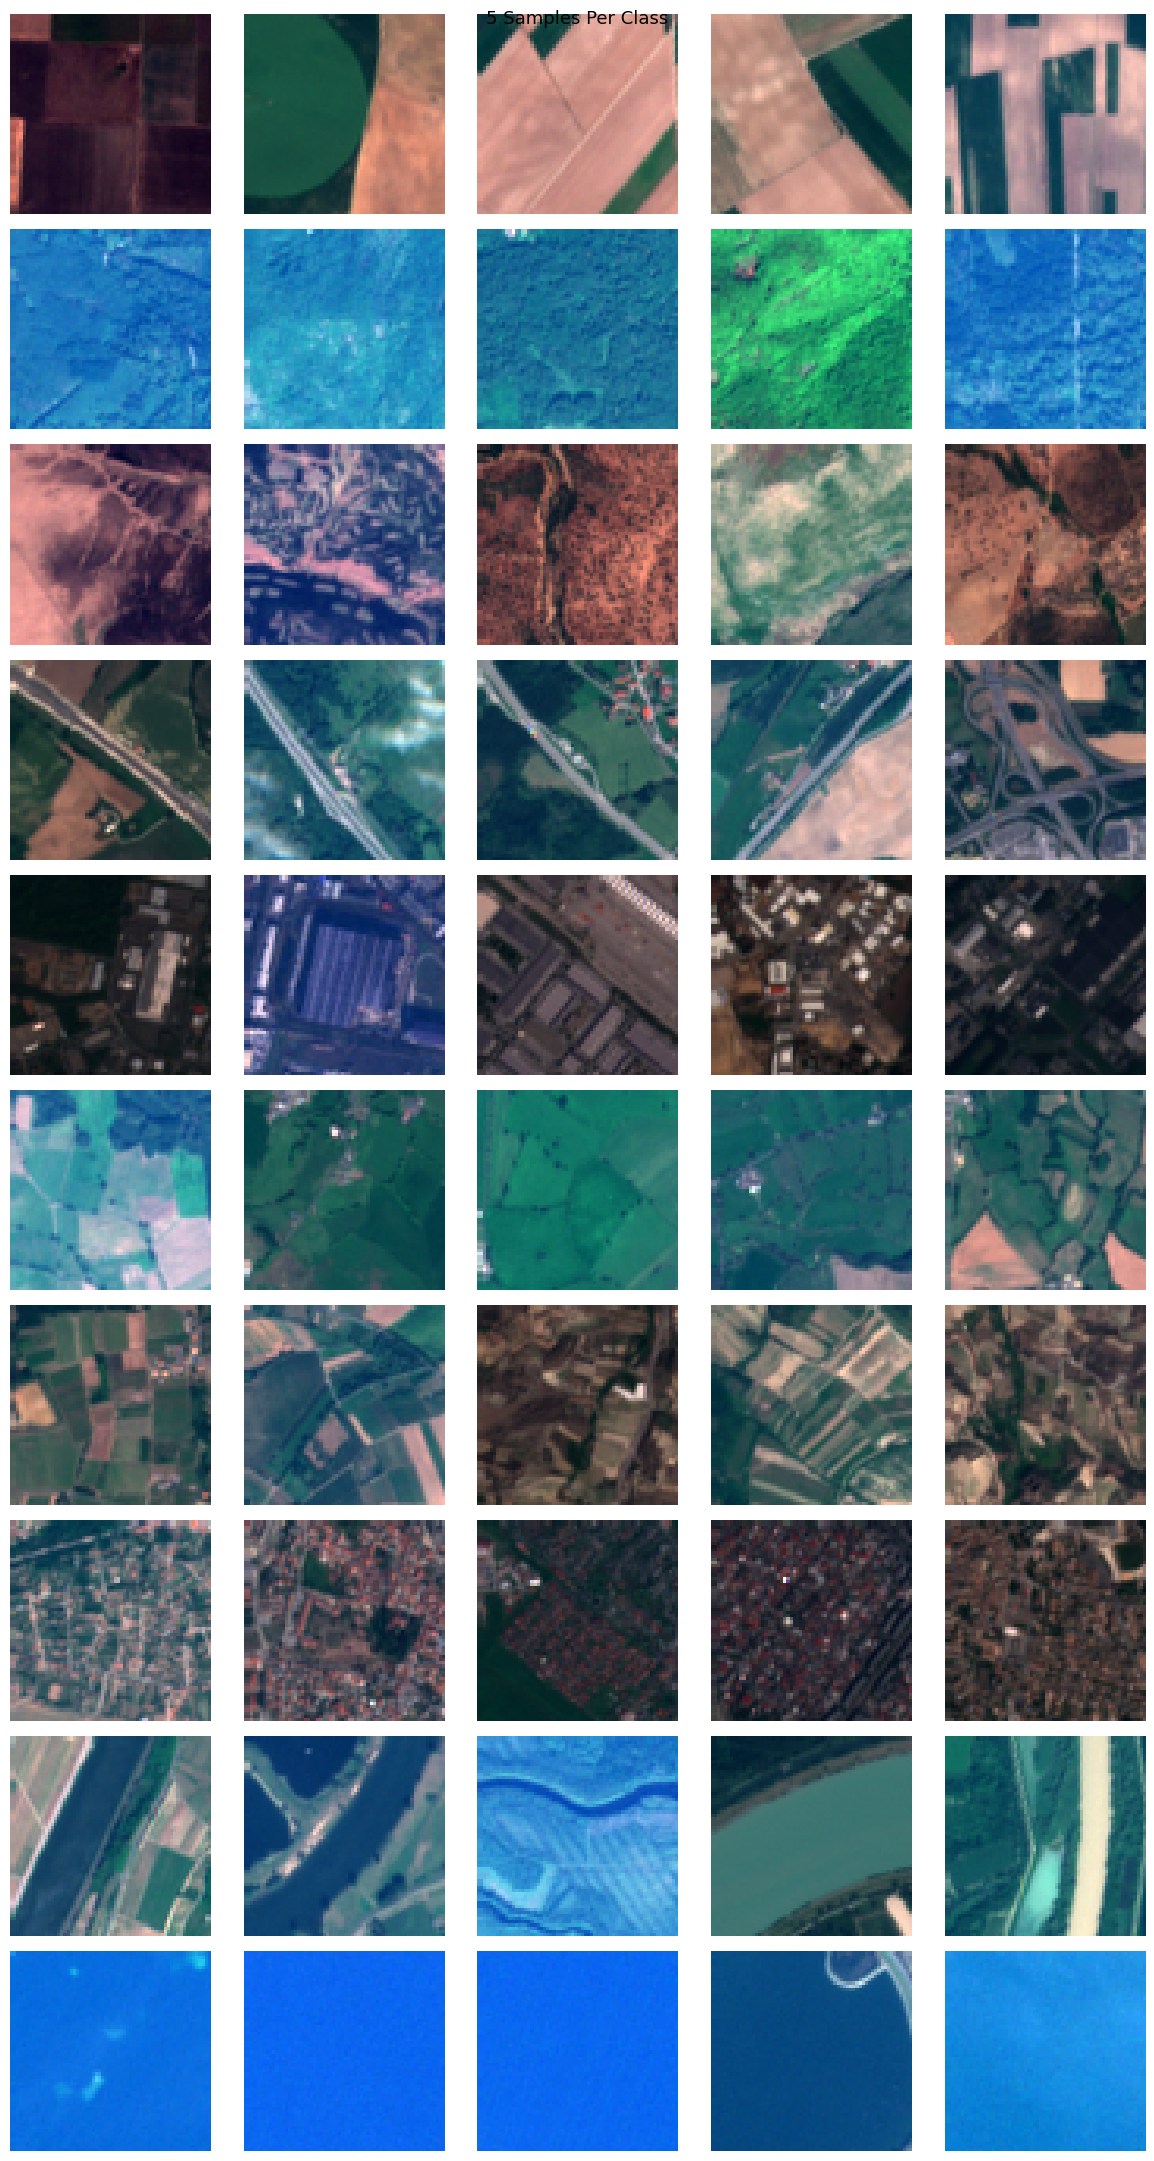

In [24]:
# Adithyan — 5 samples per class
fig, axes = plt.subplots(10, 5, figsize=(12, 22))
fig.suptitle("5 Samples Per Class", fontsize=13)

for class_idx, class_name in enumerate(dataset.classes):
    count = 0
    for i in range(len(dataset)):
        if dataset[i]['label'] == class_idx and count < 5:
            img = dataset[i]['image'][[3,2,1]].permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())
            axes[class_idx, count].imshow(img)
            axes[class_idx, count].axis('off')
            if count == 0:
                axes[class_idx, 0].set_ylabel(class_name, fontsize=8,
                                               rotation=0, labelpad=60)
            count += 1
        if count == 5:
            break

plt.tight_layout()
plt.savefig('samples_per_class.png', dpi=150)
plt.show()

In [25]:
# Adithyan — Class count verification
print("Class Count Verification:")
for name, count in class_counts.items():
    percentage = count / sum(class_counts.values()) * 100
    print(f"  {name}: {count} images ({percentage:.1f}%)")

Class Count Verification:
  AnnualCrop: 1791 images (11.1%)
  Forest: 1787 images (11.0%)
  HerbaceousVegetation: 1799 images (11.1%)
  Highway: 1505 images (9.3%)
  Industrial: 1492 images (9.2%)
  Pasture: 1195 images (7.4%)
  PermanentCrop: 1481 images (9.1%)
  Residential: 1863 images (11.5%)
  River: 1460 images (9.0%)
  SeaLake: 1827 images (11.3%)


## Adithyan's Analysis
- Dataset is well balanced with roughly equal images per class
- Training split gives sufficient data for reliable model learning
- Batch size of 32 provides stable gradient updates during training
- 5 samples per class show good visual variety within each class